In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

data = pd.read_csv(
    "worldcup_2026_task3_all_matches_fouls.csv"
)

display(data.head())

print("Dataset shape:", data.shape)
print(data["Stage"].value_counts())
print(data["Extra_Time"].value_counts())

,Date,Round,Team1,Team2,Team1_Fouls,Team2_Fouls,Extra_Time,Stage,Total_Fouls
0,11/06/2026,Group Stage,Mexico,South Africa,12,11,False,Group Stage,23
1,12/06/2026,Group Stage,South Korea,Czech Republic,9,16,False,Group Stage,25
2,12/06/2026,Group Stage,Canada,Bosnia & Herzegovina,10,20,False,Group Stage,30
3,13/06/2026,Group Stage,USA,Paraguay,13,17,False,Group Stage,30
4,13/06/2026,Group Stage,Qatar,Switzerland,12,11,False,Group Stage,23


Dataset shape: (103, 9)
Stage
Group Stage    72
Knockout       31
Name: count, dtype: int64
Extra_Time
False    96
True      7
Name: count, dtype: int64


In [4]:
extra_time_matches = [
    ("Germany", "Paraguay"),
    ("Netherlands", "Morocco"),
    ("Belgium", "Senegal"),
    ("Australia", "Egypt"),
    ("Argentina", "Cape Verde"),
    ("Switzerland", "Colombia"),
    ("Norway", "England"),
    ("Argentina", "Switzerland"),
    ("Spain", "Argentina")
]

data["Extra_Time"] = False

for team1, team2 in extra_time_matches:

    data.loc[
        (data["Team1"] == team1)
        &
        (data["Team2"] == team2),
        "Extra_Time"
    ] = True

print(
    data["Extra_Time"].value_counts()
)

display(
    data[
        data["Extra_Time"] == True
    ][
        [
            "Date",
            "Round",
            "Team1",
            "Team2",
            "Total_Fouls"
        ]
    ]
)

Extra_Time
False    94
True      9
Name: count, dtype: int64


,Date,Round,Team1,Team2,Total_Fouls
74,29/06/2026,Round of 32,Germany,Paraguay,30
75,29/06/2026,Round of 32,Netherlands,Morocco,33
80,01/07/2026,Round of 32,Belgium,Senegal,34
85,03/07/2026,Round of 32,Australia,Egypt,26
86,03/07/2026,Round of 32,Argentina,Cape Verde,25
95,07/07/2026,Round of 16,Switzerland,Colombia,43
98,11/07/2026,Quarter Final,Norway,England,18
99,11/07/2026,Quarter Final,Argentina,Switzerland,32
102,19/07/2026,Final,Spain,Argentina,46


In [5]:
print("Data types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nStage counts:")
print(data["Stage"].value_counts())

Data types:
Date           object
Round          object
Team1          object
Team2          object
Team1_Fouls     int64
Team2_Fouls     int64
Extra_Time       bool
Stage          object
Total_Fouls     int64
dtype: object

Missing values:
Date           0
Round          0
Team1          0
Team2          0
Team1_Fouls    0
Team2_Fouls    0
Extra_Time     0
Stage          0
Total_Fouls    0
dtype: int64

Duplicate rows:
0

Stage counts:
Stage
Group Stage    72
Knockout       31
Name: count, dtype: int64


In [6]:
group_population = data[
    data["Stage"] == "Group Stage"
].copy()

knockout_population = data[
    (data["Stage"] == "Knockout")
    &
    (data["Extra_Time"] == False)
].copy()

print(
    "Group-stage matches:",
    len(group_population)
)

print(
    "Valid knockout matches:",
    len(knockout_population)
)

Group-stage matches: 72
Valid knockout matches: 22


In [7]:
group_sample = group_population.sample(
    n=22,
    random_state=42
)

knockout_sample = knockout_population.copy()

sample = pd.concat(
    [
        group_sample,
        knockout_sample
    ],
    ignore_index=True
)

print(
    sample["Stage"].value_counts()
)

Stage
Group Stage    22
Knockout       22
Name: count, dtype: int64


In [8]:
display(
    sample[
        [
            "Date",
            "Round",
            "Team1",
            "Team2",
            "Stage",
            "Team1_Fouls",
            "Team2_Fouls",
            "Total_Fouls"
        ]
    ]
)

,Date,Round,Team1,Team2,Stage,Team1_Fouls,Team2_Fouls,Total_Fouls
0,13/06/2026,Group Stage,Qatar,Switzerland,Group Stage,12,11,23
1,27/06/2026,Group Stage,Cape Verde,Saudi Arabia,Group Stage,10,16,26
2,17/06/2026,Group Stage,Argentina,Algeria,Group Stage,13,8,21
3,11/06/2026,Group Stage,Mexico,South Africa,Group Stage,12,11,23
4,19/06/2026,Group Stage,USA,Australia,Group Stage,12,16,28
5,24/06/2026,Group Stage,Morocco,Haiti,Group Stage,10,18,28
6,15/06/2026,Group Stage,Ivory Coast,Ecuador,Group Stage,10,13,23
7,21/06/2026,Group Stage,Ecuador,Curacao,Group Stage,7,10,17
8,15/06/2026,Group Stage,Spain,Cape Verde,Group Stage,10,1,11
9,25/06/2026,Group Stage,Curacao,Ivory Coast,Group Stage,11,6,17


In [9]:
descriptive_stats = (
    sample
    .groupby("Stage")["Total_Fouls"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
)

display(
    descriptive_stats.round(2)
)

,count,mean,median,standard_deviation,minimum,maximum
Stage,,,,,,
Group Stage,22,23.32,23.0,7.10,11,38
Knockout,22,22.73,23.0,5.33,13,38


In [10]:
group_fouls = group_sample[
    "Total_Fouls"
]

knockout_fouls = knockout_sample[
    "Total_Fouls"
]

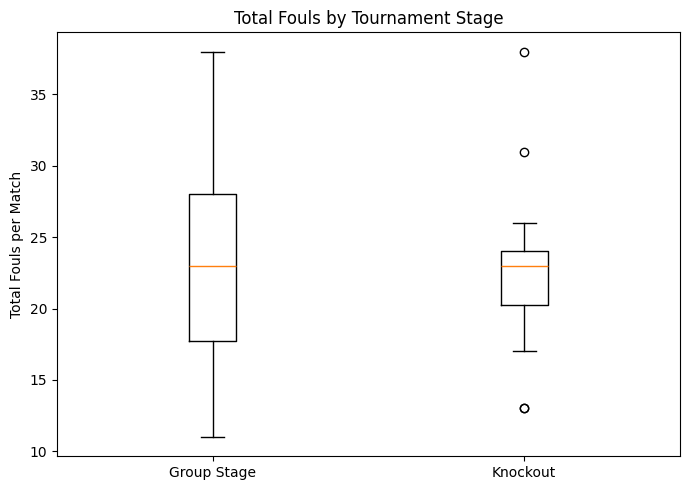

In [11]:
plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    [
        group_fouls,
        knockout_fouls
    ],
    tick_labels=[
        "Group Stage",
        "Knockout"
    ]
)

plt.title(
    "Total Fouls by Tournament Stage"
)

plt.ylabel(
    "Total Fouls per Match"
)

plt.tight_layout()
plt.show()

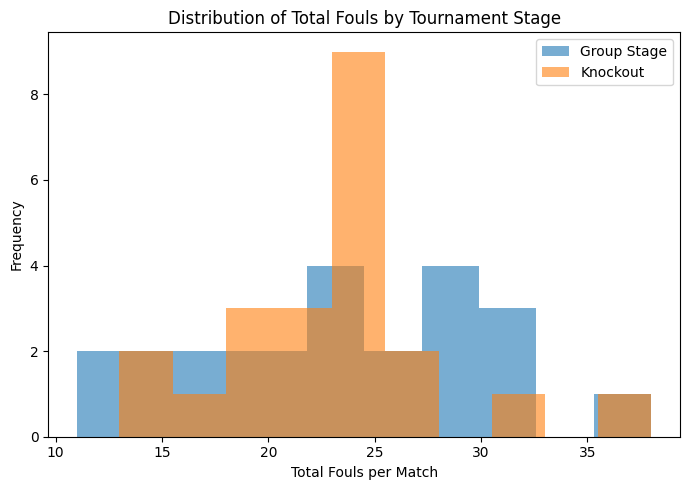

In [12]:
plt.figure(
    figsize=(7, 5)
)

plt.hist(
    group_fouls,
    alpha=0.6,
    label="Group Stage"
)

plt.hist(
    knockout_fouls,
    alpha=0.6,
    label="Knockout"
)

plt.xlabel(
    "Total Fouls per Match"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Total Fouls by Tournament Stage"
)

plt.legend()

plt.tight_layout()
plt.show()

In [13]:
def confidence_interval(values):

    n = len(values)
    mean = values.mean()

    standard_error = stats.sem(
        values
    )

    margin = (
        stats.t.ppf(
            0.975,
            df=n - 1
        )
        *
        standard_error
    )

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


group_mean, group_lower, group_upper = (
    confidence_interval(
        group_fouls
    )
)

ko_mean, ko_lower, ko_upper = (
    confidence_interval(
        knockout_fouls
    )
)


print(
    "Group-stage mean:",
    round(group_mean, 2)
)

print(
    "Group-stage 95% CI:",
    round(group_lower, 2),
    "to",
    round(group_upper, 2)
)


print(
    "\nKnockout mean:",
    round(ko_mean, 2)
)

print(
    "Knockout 95% CI:",
    round(ko_lower, 2),
    "to",
    round(ko_upper, 2)
)


Group-stage mean: 23.32
Group-stage 95% CI: 20.17 to 26.47

Knockout mean: 22.73
Knockout 95% CI: 20.36 to 25.09


In [14]:
group_shapiro = stats.shapiro(
    group_fouls
)

knockout_shapiro = stats.shapiro(
    knockout_fouls
)

print(
    "Group-stage Shapiro-Wilk p-value:",
    round(
        group_shapiro.pvalue,
        4
    )
)

print(
    "Knockout Shapiro-Wilk p-value:",
    round(
        knockout_shapiro.pvalue,
        4
    )
)

Group-stage Shapiro-Wilk p-value: 0.7477
Knockout Shapiro-Wilk p-value: 0.029


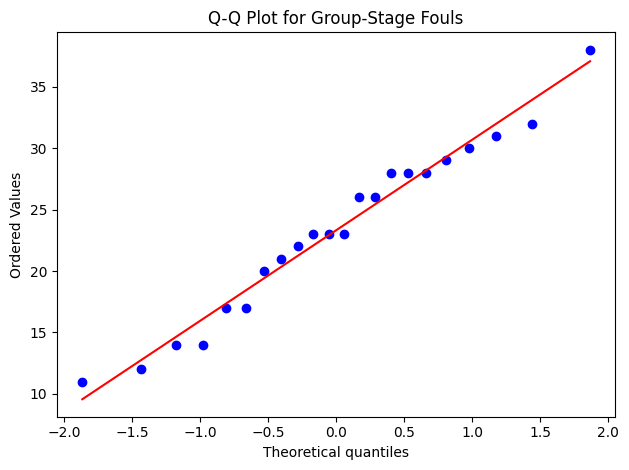

In [15]:
stats.probplot(
    group_fouls,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Group-Stage Fouls"
)

plt.tight_layout()
plt.show()

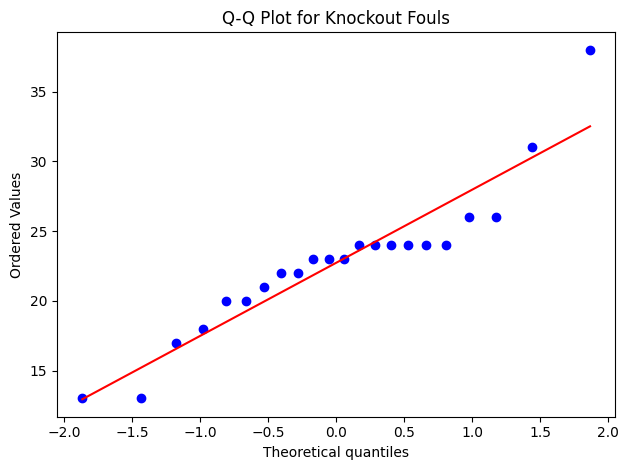

In [16]:
stats.probplot(
    knockout_fouls,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot for Knockout Fouls"
)

plt.tight_layout()
plt.show()

In [17]:
t_statistic, p_value = stats.ttest_ind(
    group_fouls,
    knockout_fouls,
    equal_var=False
)

print(
    "t-statistic:",
    round(
        t_statistic,
        4
    )
)

print(
    "p-value:",
    round(
        p_value,
        4
    )
)

t-statistic: 0.3122
p-value: 0.7566


In [18]:
alpha = 0.05

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

    print(
        "There is statistically significant evidence "
        "of a difference in mean total fouls between "
        "group-stage and knockout matches."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

    print(
        "There is insufficient statistical evidence "
        "of a difference in mean total fouls between "
        "group-stage and knockout matches."
    )

Fail to reject the null hypothesis.
There is insufficient statistical evidence of a difference in mean total fouls between group-stage and knockout matches.


In [19]:
mean_difference = (
    group_fouls.mean()
    -
    knockout_fouls.mean()
)

se_difference = np.sqrt(
    group_fouls.var(ddof=1)
    / len(group_fouls)
    +
    knockout_fouls.var(ddof=1)
    / len(knockout_fouls)
)

numerator = (
    group_fouls.var(ddof=1)
    / len(group_fouls)
    +
    knockout_fouls.var(ddof=1)
    / len(knockout_fouls)
) ** 2

denominator = (
    (
        group_fouls.var(ddof=1)
        / len(group_fouls)
    ) ** 2
    / (
        len(group_fouls) - 1
    )
    +
    (
        knockout_fouls.var(ddof=1)
        / len(knockout_fouls)
    ) ** 2
    / (
        len(knockout_fouls) - 1
    )
)

welch_df = (
    numerator
    /
    denominator
)

t_critical = stats.t.ppf(
    0.975,
    df=welch_df
)

lower_difference = (
    mean_difference
    -
    t_critical
    * se_difference
)

upper_difference = (
    mean_difference
    +
    t_critical
    * se_difference
)

print(
    "Mean difference:",
    round(
        mean_difference,
        2
    )
)

print(
    "95% CI for mean difference:",
    round(
        lower_difference,
        2
    ),
    "to",
    round(
        upper_difference,
        2
    )
)

Mean difference: 0.59
95% CI for mean difference: -3.24 to 4.42


In [20]:
n1 = len(group_fouls)
n2 = len(knockout_fouls)

sd1 = group_fouls.std(ddof=1)
sd2 = knockout_fouls.std(ddof=1)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * sd1**2
        +
        (n2 - 1) * sd2**2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    group_fouls.mean()
    -
    knockout_fouls.mean()
) / pooled_sd

print(
    "Cohen's d:",
    round(cohens_d, 2)
)

Cohen's d: 0.09
